In [ ]:
!pip install ultralytics --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 62.7 MB/s eta 0:00:00


In [ ]:
# ==========================================================
# 🌾 Test Quantized TensorFlow Lite Model on Single Image
# ✅ With Visual + Text Detection Output
# ==========================================================

from ultralytics import YOLO
from google.colab import files
from IPython.display import Image, display
import os, glob

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# STEP 1️⃣ – Upload your test image
print("📸 Please upload a single image (weed/crop field photo)...")
uploaded = files.upload()

📸 Please upload a single image (weed/crop field photo)...


Saving 1624287985003_frame_6384.jpg to 1624287985003_frame_6384.jpg


In [ ]:
# Get uploaded image path
image_path = list(uploaded.keys())[0]
print(f"✅ Image uploaded: {image_path}")

✅ Image uploaded: 1624287985003_frame_6384.jpg


In [ ]:
# STEP 2️⃣ – Load your quantized TFLite model
tflite_path = "/content/yolov_distill_best_int8.tflite"
model_tflite = YOLO(tflite_path)
print("✅ Model loaded successfully!")

WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.
✅ Model loaded successfully!


In [ ]:
# STEP 3️⃣ – Run inference
results = model_tflite.predict(
    source=image_path,
    conf=0.26,   # confidence threshold
    save=True,   # saves annotated image to runs/detect/predict/
    show=False
)
print("✅ Inference complete!\n")

Loading /content/yolov_distill_best_int8.tflite for TensorFlow Lite inference...



/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


image 1/1 /content/1624287985003_frame_6384.jpg: 416x416 5 crops, 12 weeds, 121.9ms
Speed: 59.7ms preprocess, 121.9ms inference, 97.1ms postprocess per image at shape (1, 3, 416, 416)
Results saved to /content/runs/detect/predict
✅ Inference complete!



🖼️ Displaying the annotated image:


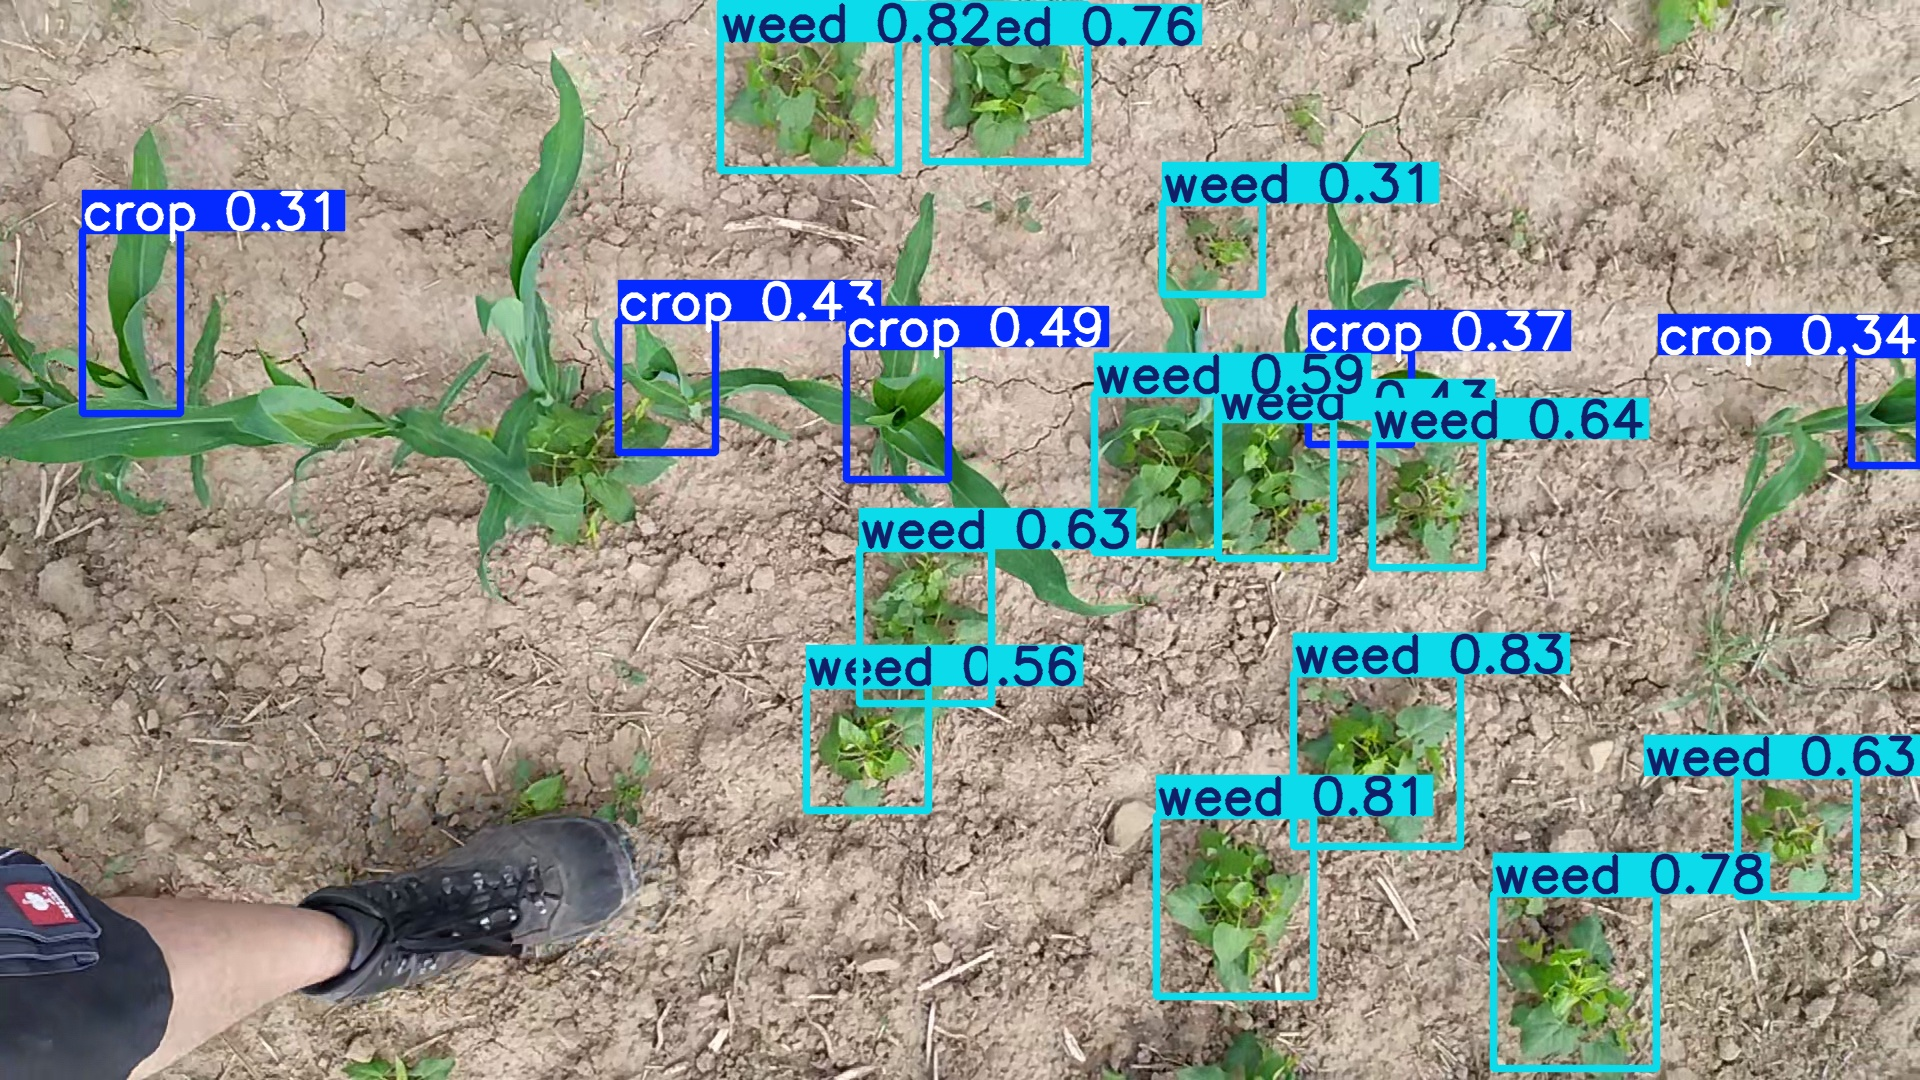

In [ ]:
# STEP 4️⃣ – Display annotated image
predicted_images = sorted(glob.glob("runs/detect/predict/*.jpg"))

if predicted_images:
    print("🖼️ Displaying the annotated image:")
    display(Image(filename=predicted_images[-1]))
else:
    print("⚠️ No prediction image found (try lowering conf threshold).")


In [ ]:
# STEP 5️⃣ – Print detection details (class, confidence, bounding boxes)
print("\n📋 Detection Results:")

for r in results:
    boxes = r.boxes
    if boxes is not None and len(boxes) > 0:
        for box in boxes:
            cls = int(box.cls[0])
            label = model_tflite.names[cls]  # get class name ('weed' or 'crop')
            conf = float(box.conf[0])
            xyxy = box.xyxy[0].tolist()  # [x1, y1, x2, y2]
            x1, y1, x2, y2 = [round(v, 2) for v in xyxy]

            print(f"🔹 {label.upper()} detected with {conf:.2f} confidence "
                  f"at [x1={x1}, y1={y1}, x2={x2}, y2={y2}]")
    else:
        print("⚠️ No objects detected in this image.")


📋 Detection Results:
🔹 WEED detected with 0.83 confidence at [x1=1293.11, y1=673.67, x2=1460.47, y2=846.45]
🔹 WEED detected with 0.82 confidence at [x1=720.31, y1=1.92, x2=898.06, y2=170.5]
🔹 WEED detected with 0.81 confidence at [x1=1156.77, y1=815.84, x2=1313.85, y2=996.23]
🔹 WEED detected with 0.78 confidence at [x1=1493.84, y1=893.19, x2=1656.16, y2=1068.34]
🔹 WEED detected with 0.76 confidence at [x1=925.94, y1=4.87, x2=1087.62, y2=161.77]
🔹 WEED detected with 0.64 confidence at [x1=1372.03, y1=438.68, x2=1482.16, y2=567.72]
🔹 WEED detected with 0.63 confidence at [x1=1737.25, y1=775.35, x2=1856.87, y2=896.89]
🔹 WEED detected with 0.63 confidence at [x1=859.69, y1=548.79, x2=991.54, y2=703.41]
🔹 WEED detected with 0.59 confidence at [x1=1094.95, y1=393.67, x2=1217.97, y2=552.8]
🔹 WEED detected with 0.56 confidence at [x1=806.25, y1=685.76, x2=928.22, y2=810.87]
🔹 CROP detected with 0.49 confidence at [x1=846.12, y1=346.92, x2=948.03, y2=479.01]
🔹 WEED detected with 0.43 confidenc

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!unzip -q "/content/drive/MyDrive/Crop_weedDataset.v2i.yolov8.zip" -d "/content/Crop_weedDataset"



Mounted at /content/drive


In [ ]:
!ls -R /content/Crop_weedDataset | head -n 50


/content/Crop_weedDataset:
data.yaml
README.dataset.txt
README.roboflow.txt
test
train
valid

/content/Crop_weedDataset/test:
images
labels

/content/Crop_weedDataset/test/images:
1623872870546_frame_2672_jpg.rf.9ab72922dcee8944275af98804de080a.jpg
1623872870546_frame_2715_jpg.rf.f70f0d78aee84180ce86225a86d863c0.jpg
1623872870546_frame_2_jpg.rf.6b1f585cd5a8d379146f6bfe24c3e8a5.jpg
1623872870546_frame_3108_jpg.rf.24e81c5cbc52cffe617451a709a4a389.jpg
1624281034515_frame_129_jpg.rf.eacc796f6c5f26cc3469791afa4be7d7.jpg
1624281034515_frame_4936_jpg.rf.6bec1f078f421f6cffe8bc8b62a6cb9e.jpg
1624281034515_frame_5457_jpg.rf.051c16fde97590d2dd9add7f48037562.jpg
1624281034515_frame_6336_jpg.rf.c733548d9675d21277d9b18f3a649522.jpg
1624281034515_frame_6739_jpg.rf.21085da0c96372e46c466dd52692124b.jpg
1624281374291_frame_4413_jpg.rf.429756ea175394cb7ad29e36451a4716.jpg
1624281374291_frame_4586_jpg.rf.8f64088f035ad12d4a7f170f44238cd9.jpg
1624281374291_frame_4606_jpg.rf.8a1e49feb4b2f7f9b0c5923b34cbbed1.

✅ Quantized YOLOv11n model loaded successfully!
Ultralytics 8.4.9 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Loading /content/yolov_distill_best_int8.tflite for TensorFlow Lite inference...
Setting batch=1 input of shape (1, 3, 416, 416)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1801.8±830.5 MB/s, size: 118.0 KB)
val: Scanning /content/Crop_weedDataset/valid/labels... 50 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 50/50 836.6it/s 0.1s
val: New cache created: /content/Crop_weedDataset/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 50/50 8.9it/s 5.6s
                   all         50        590      0.655       0.57      0.541      0.186
                  crop         39        269      0.596      0.542      0.457      0.129
                  weed         34        321      0.714      0.598      0.626      0.242
Speed: 0.7ms preprocess, 96.5ms inference, 0.0ms loss, 2.6ms p

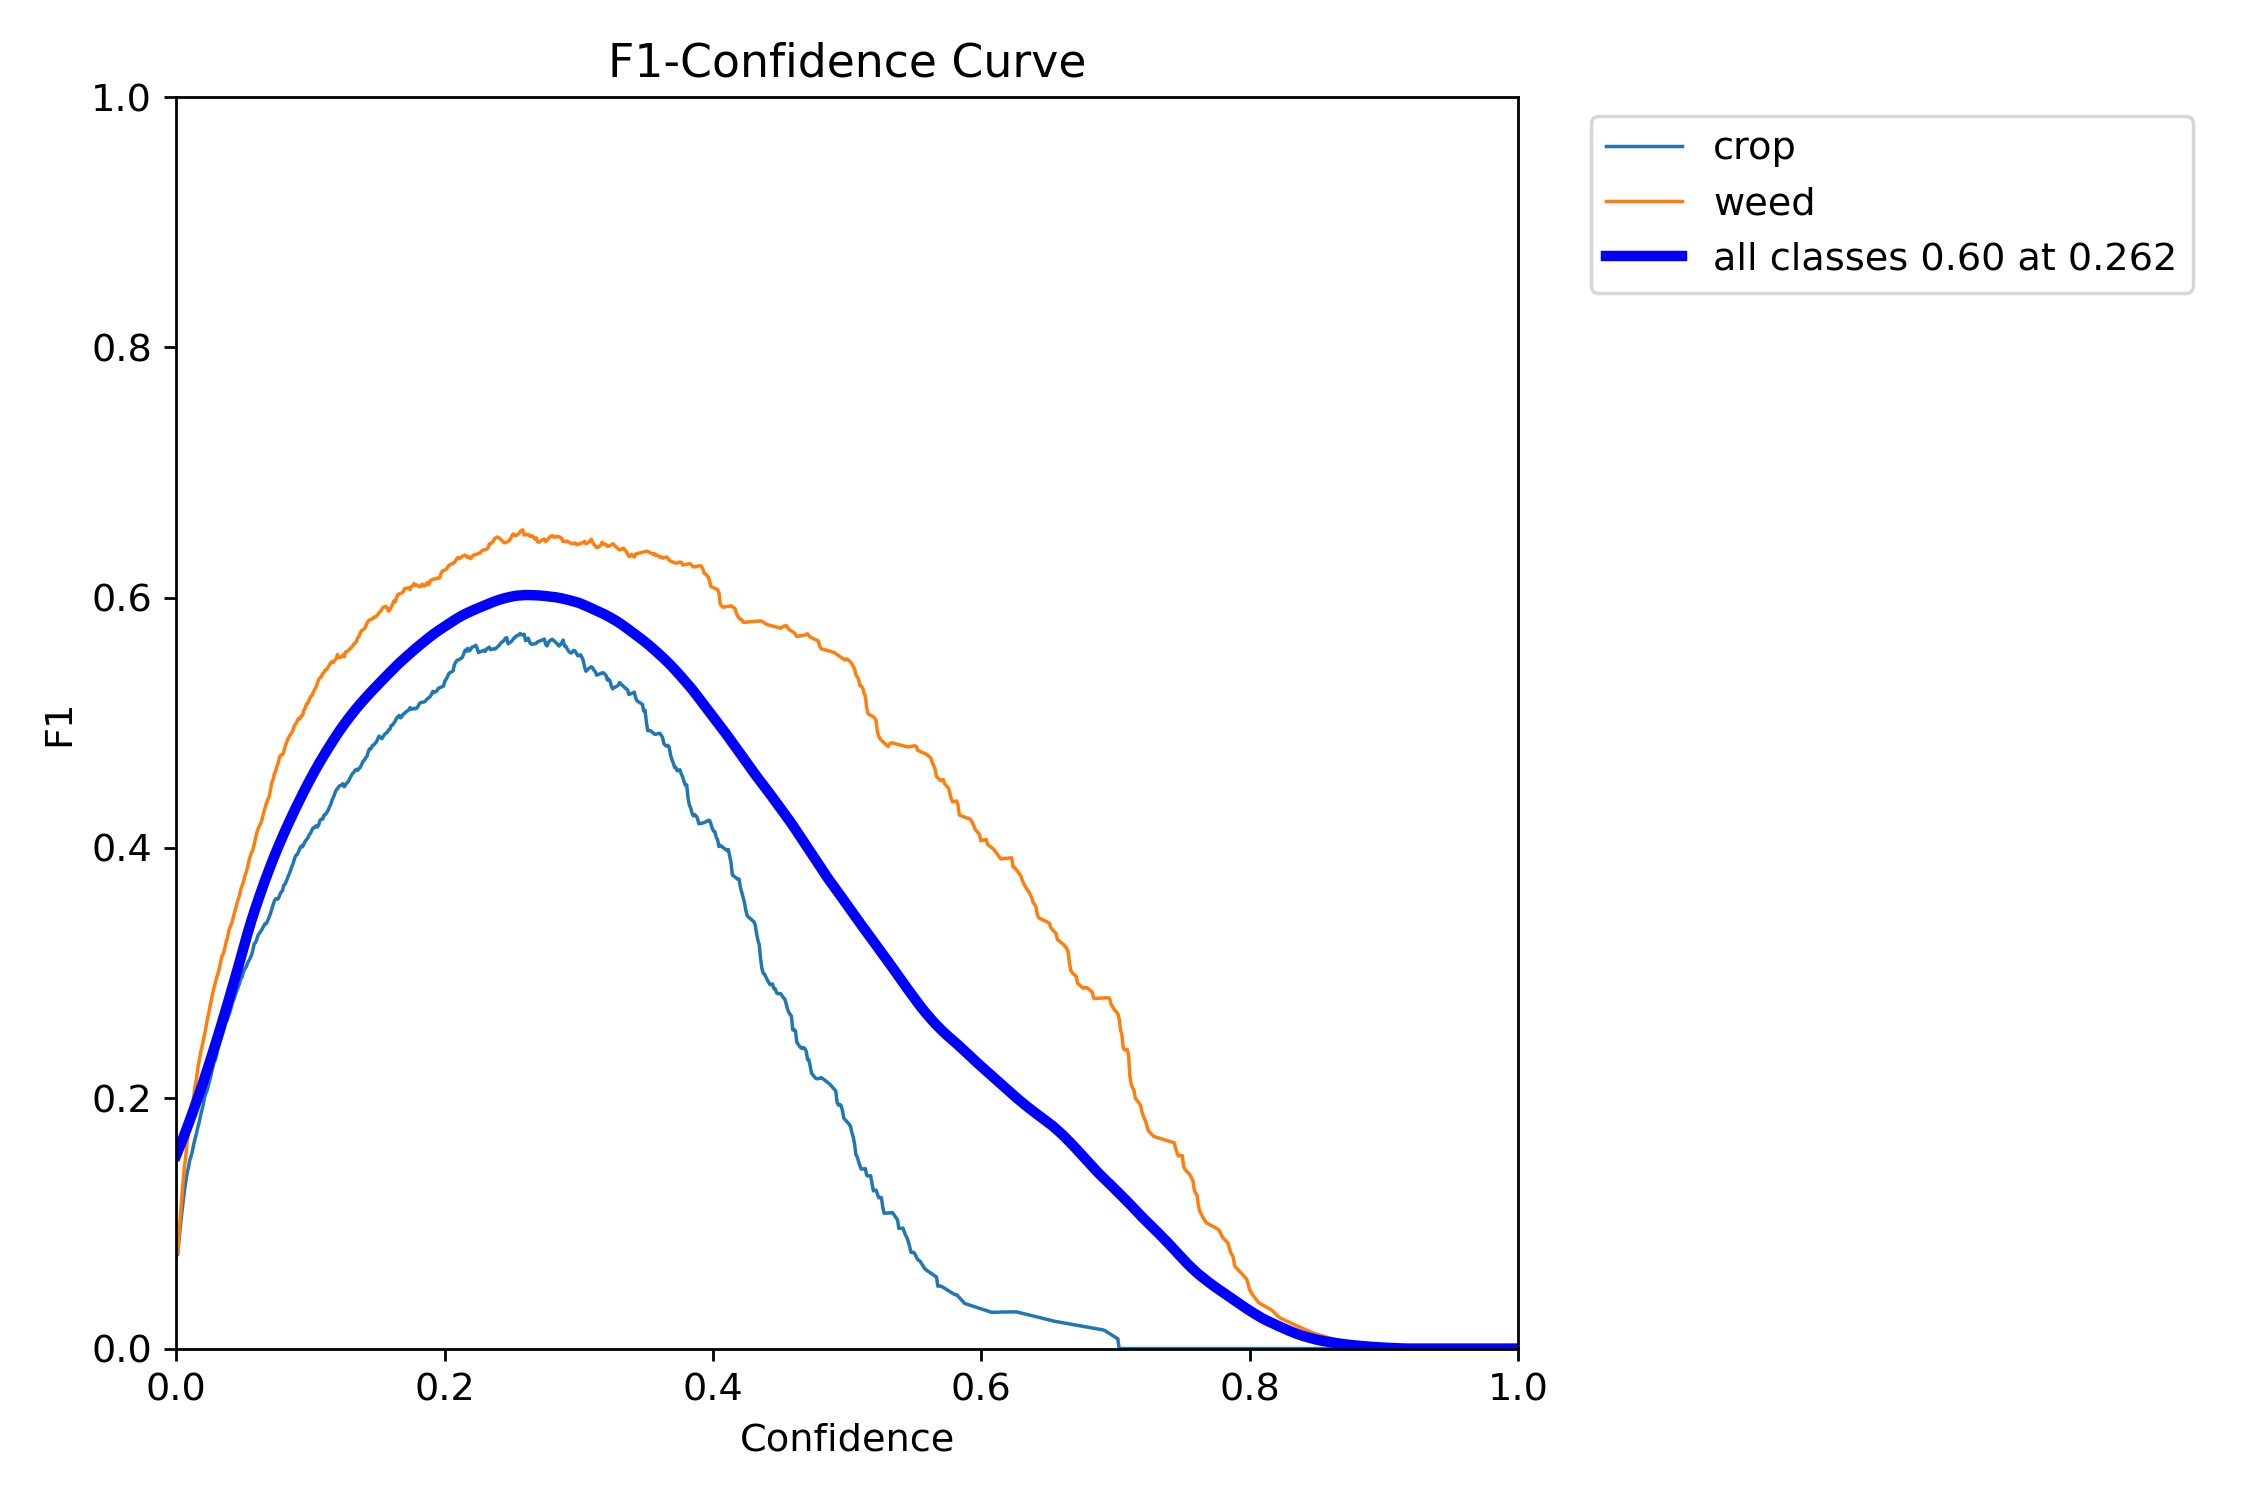

Showing: BoxPR_curve.png


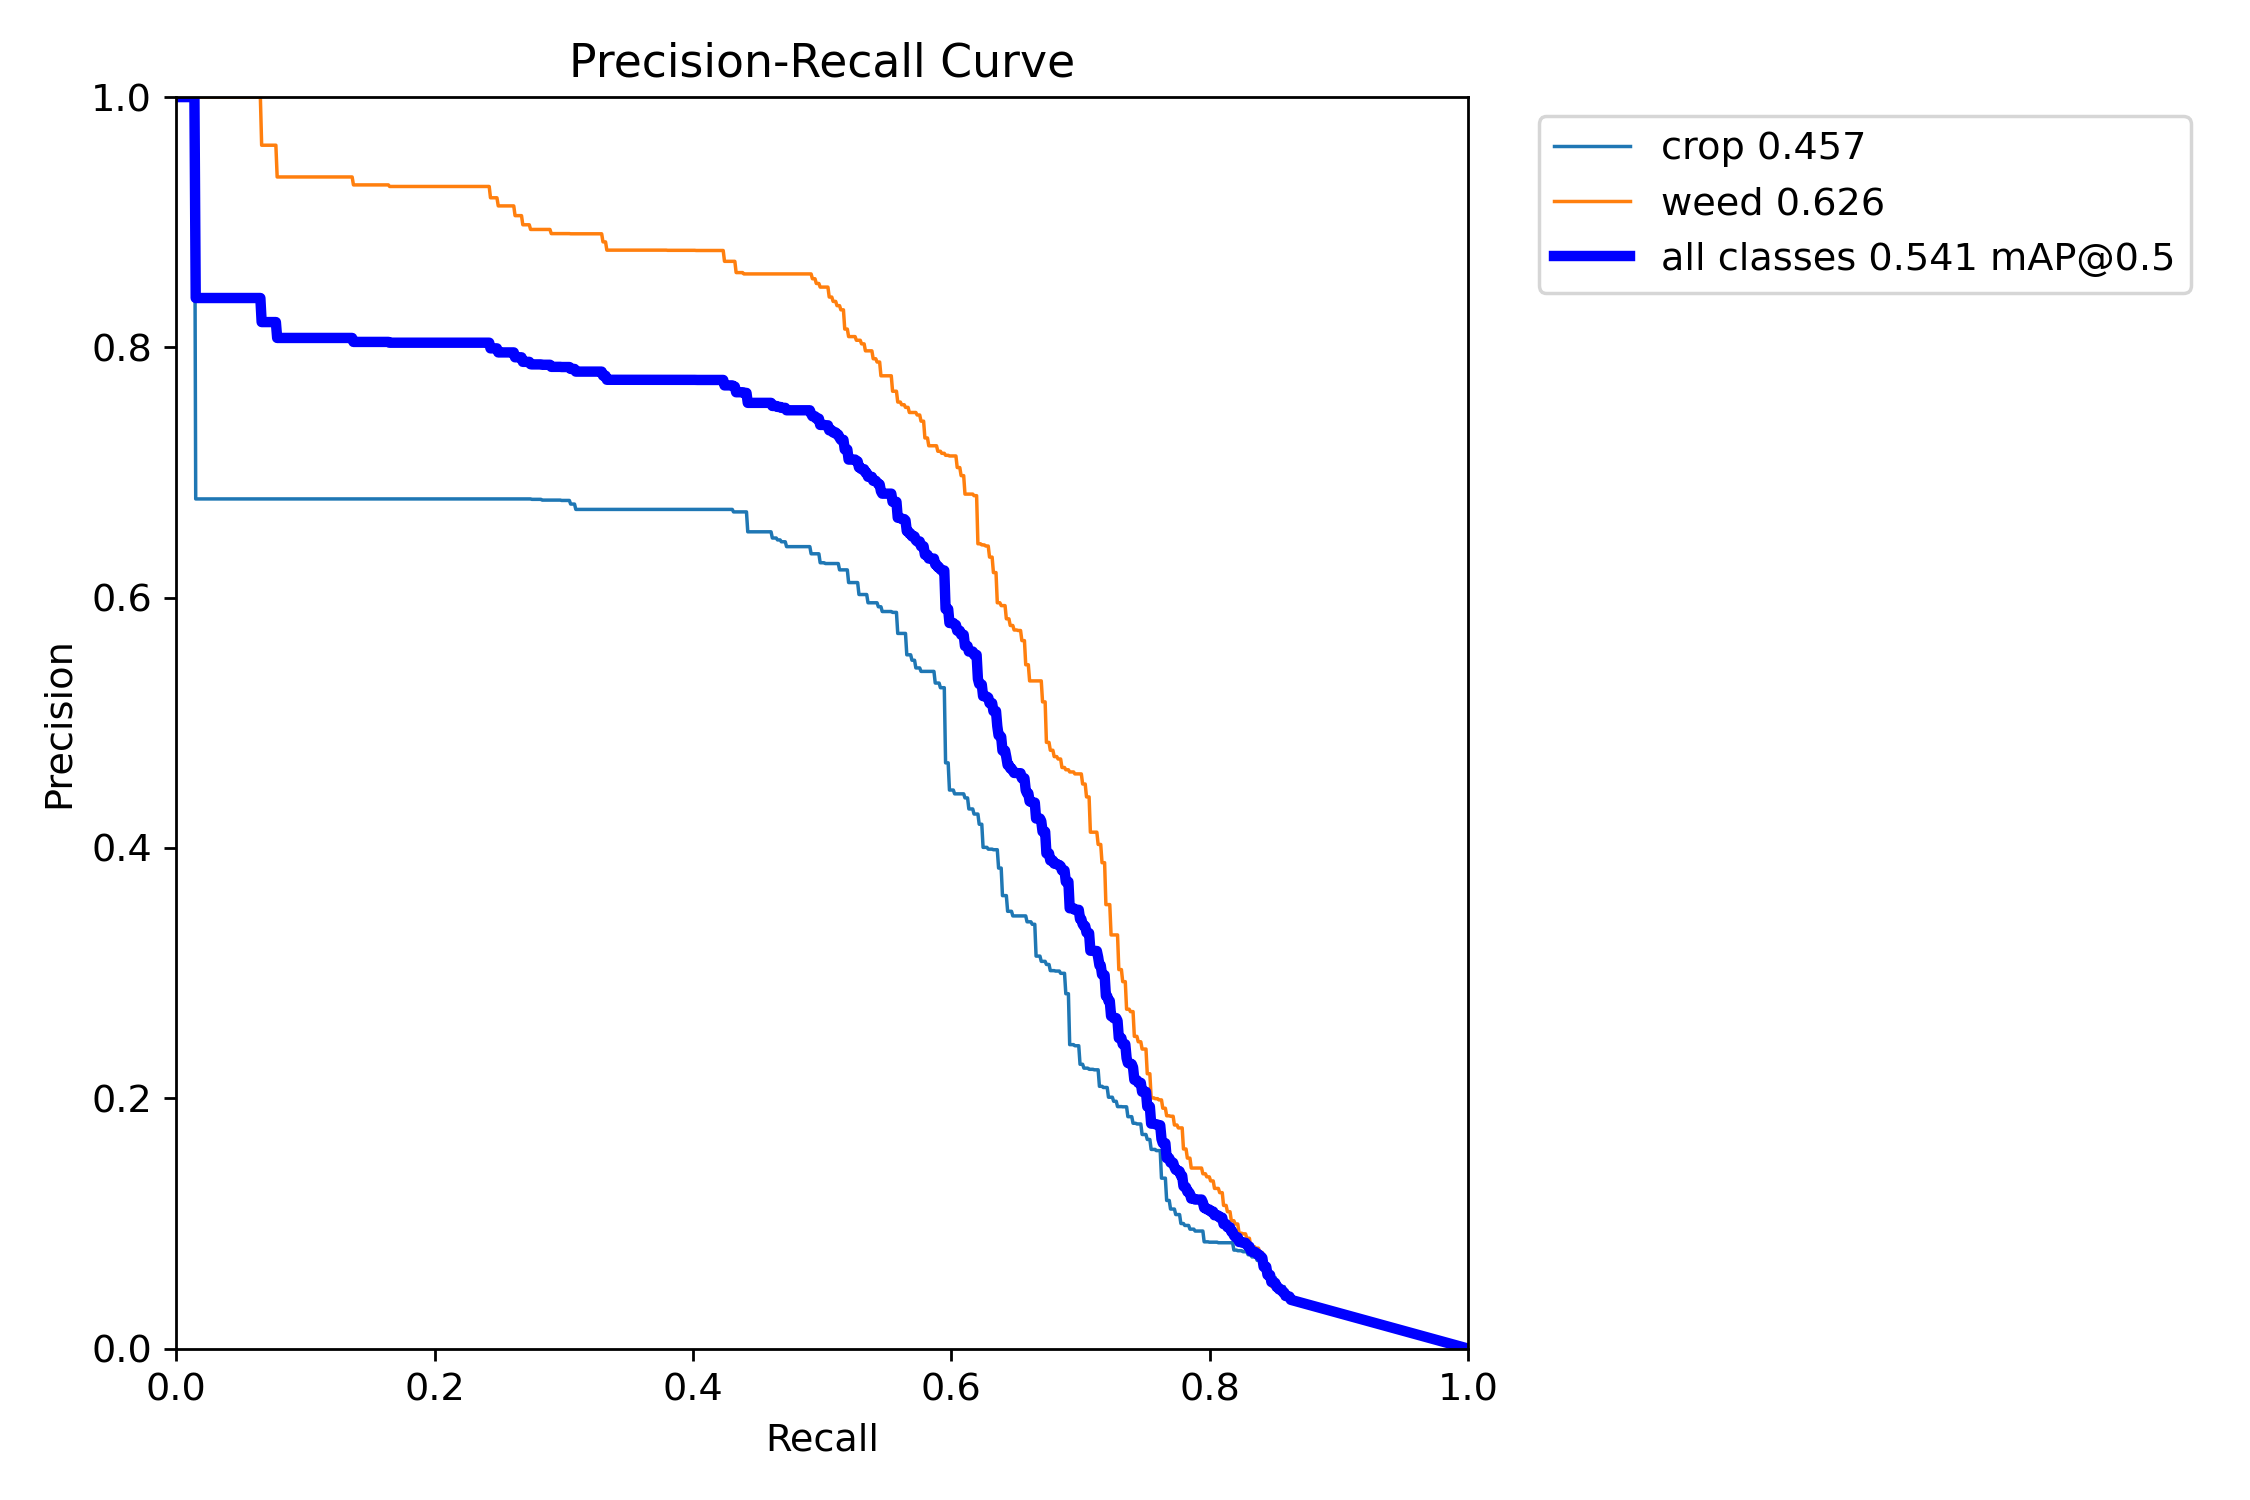

Showing: BoxP_curve.png


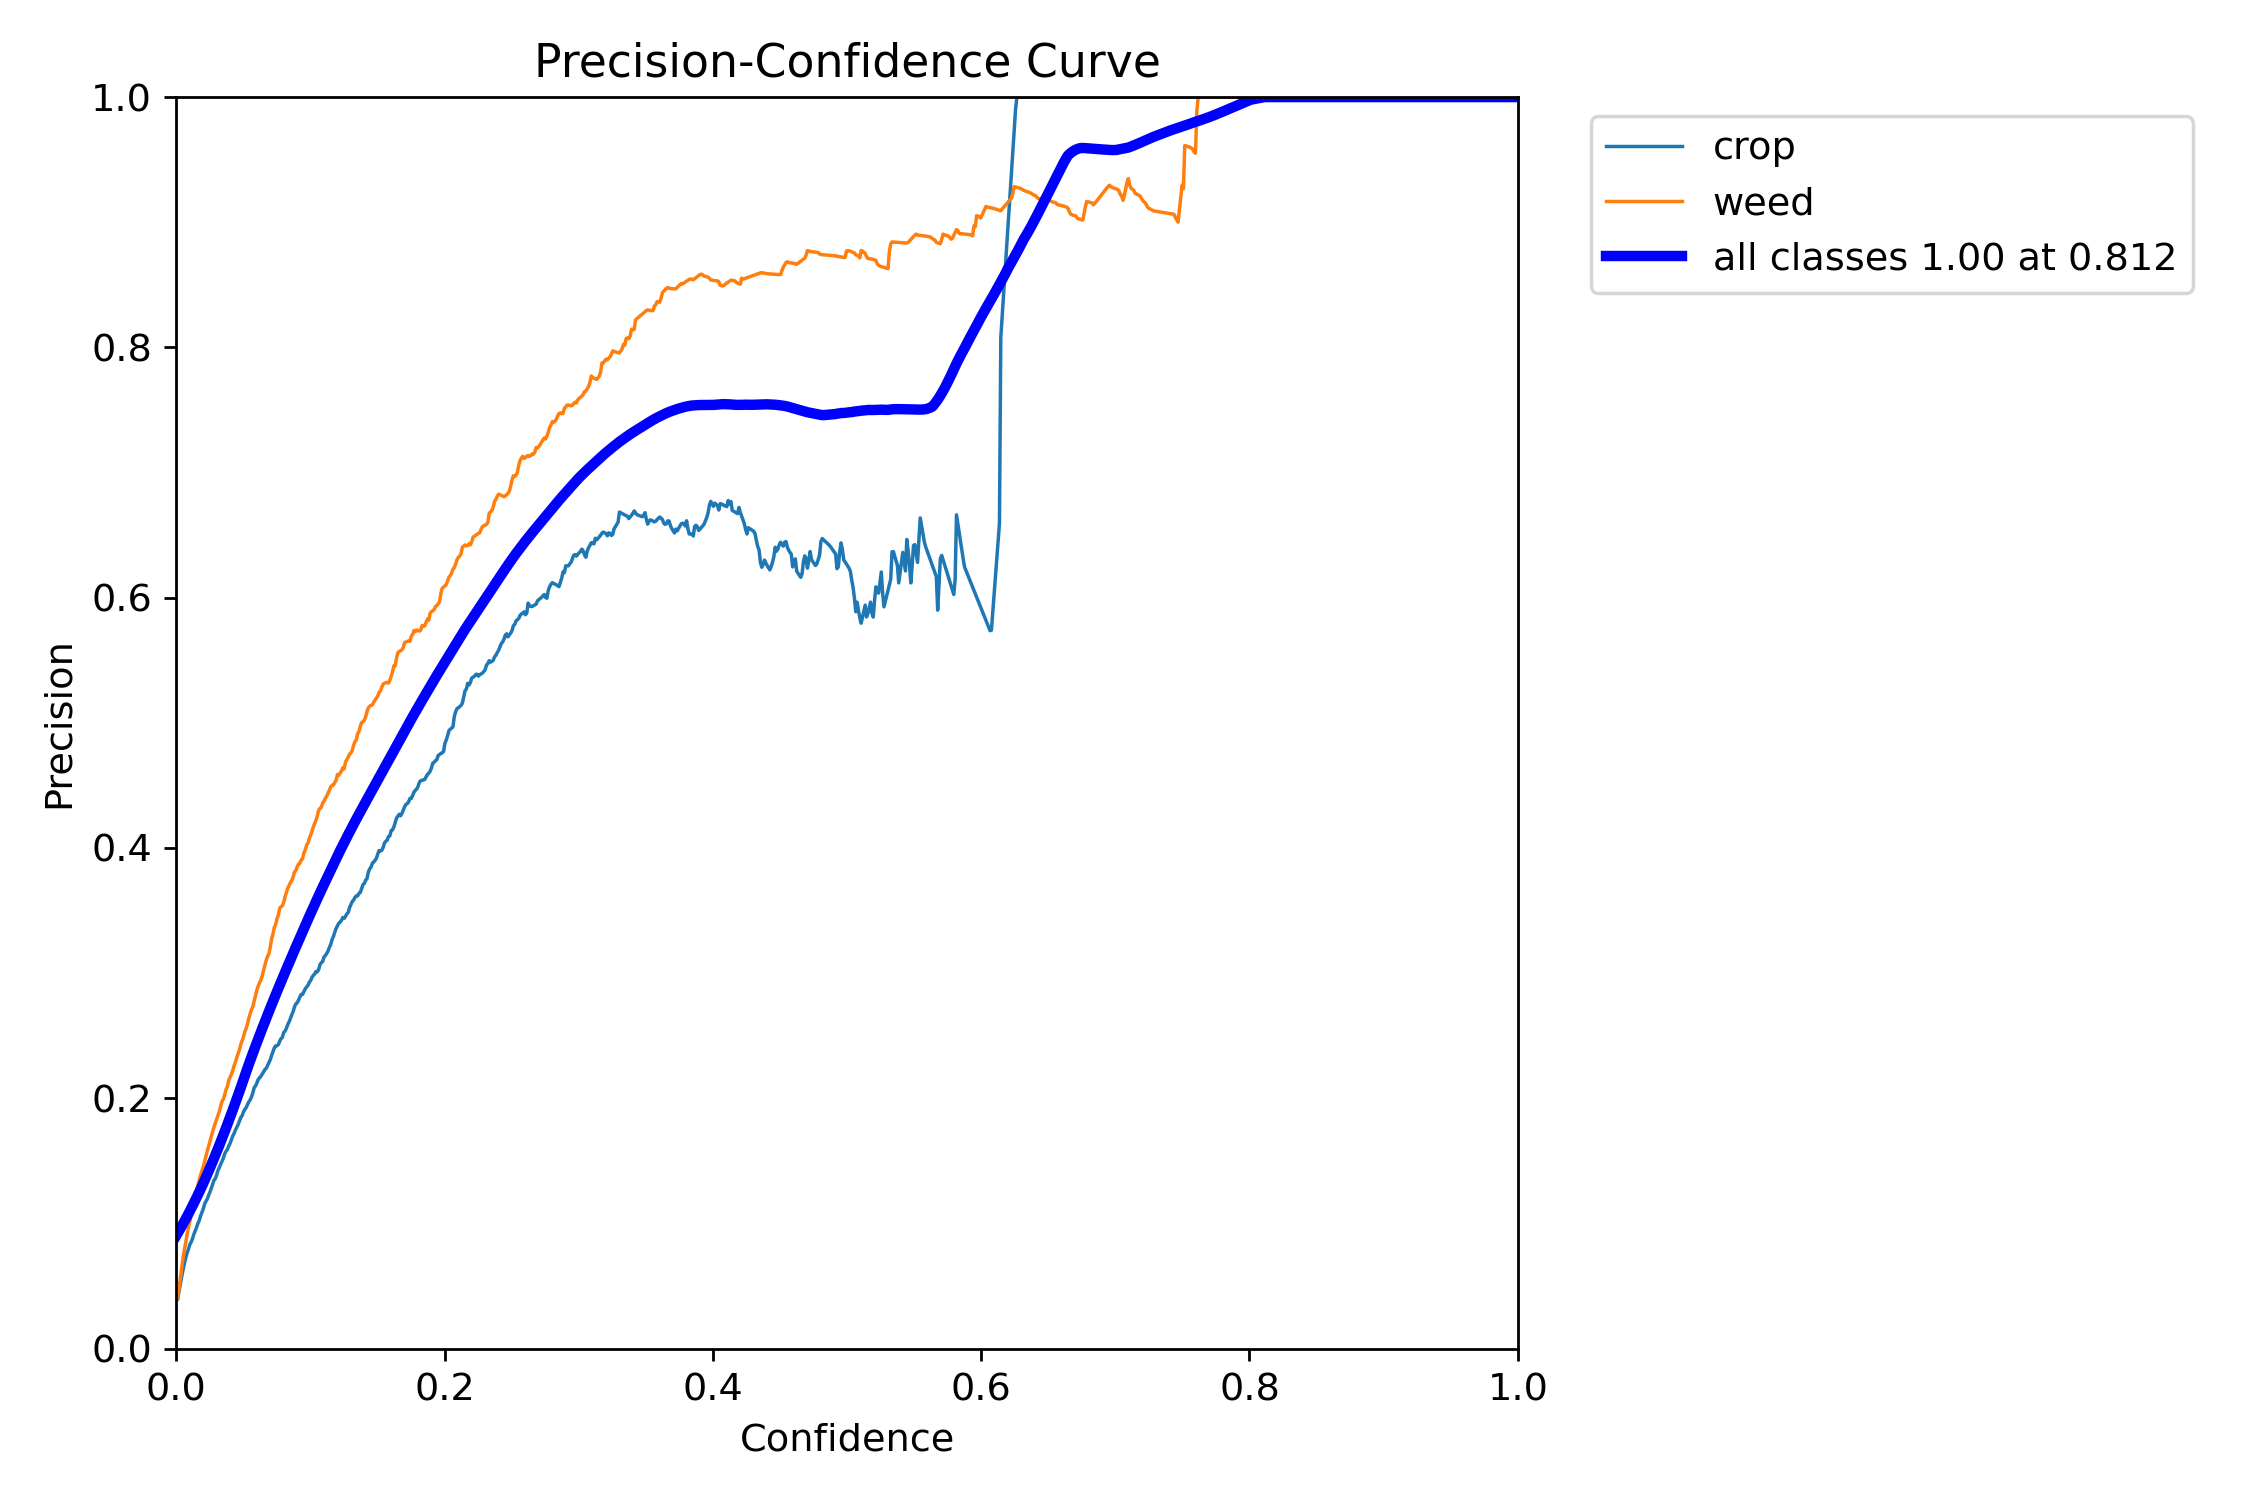

Showing: BoxR_curve.png


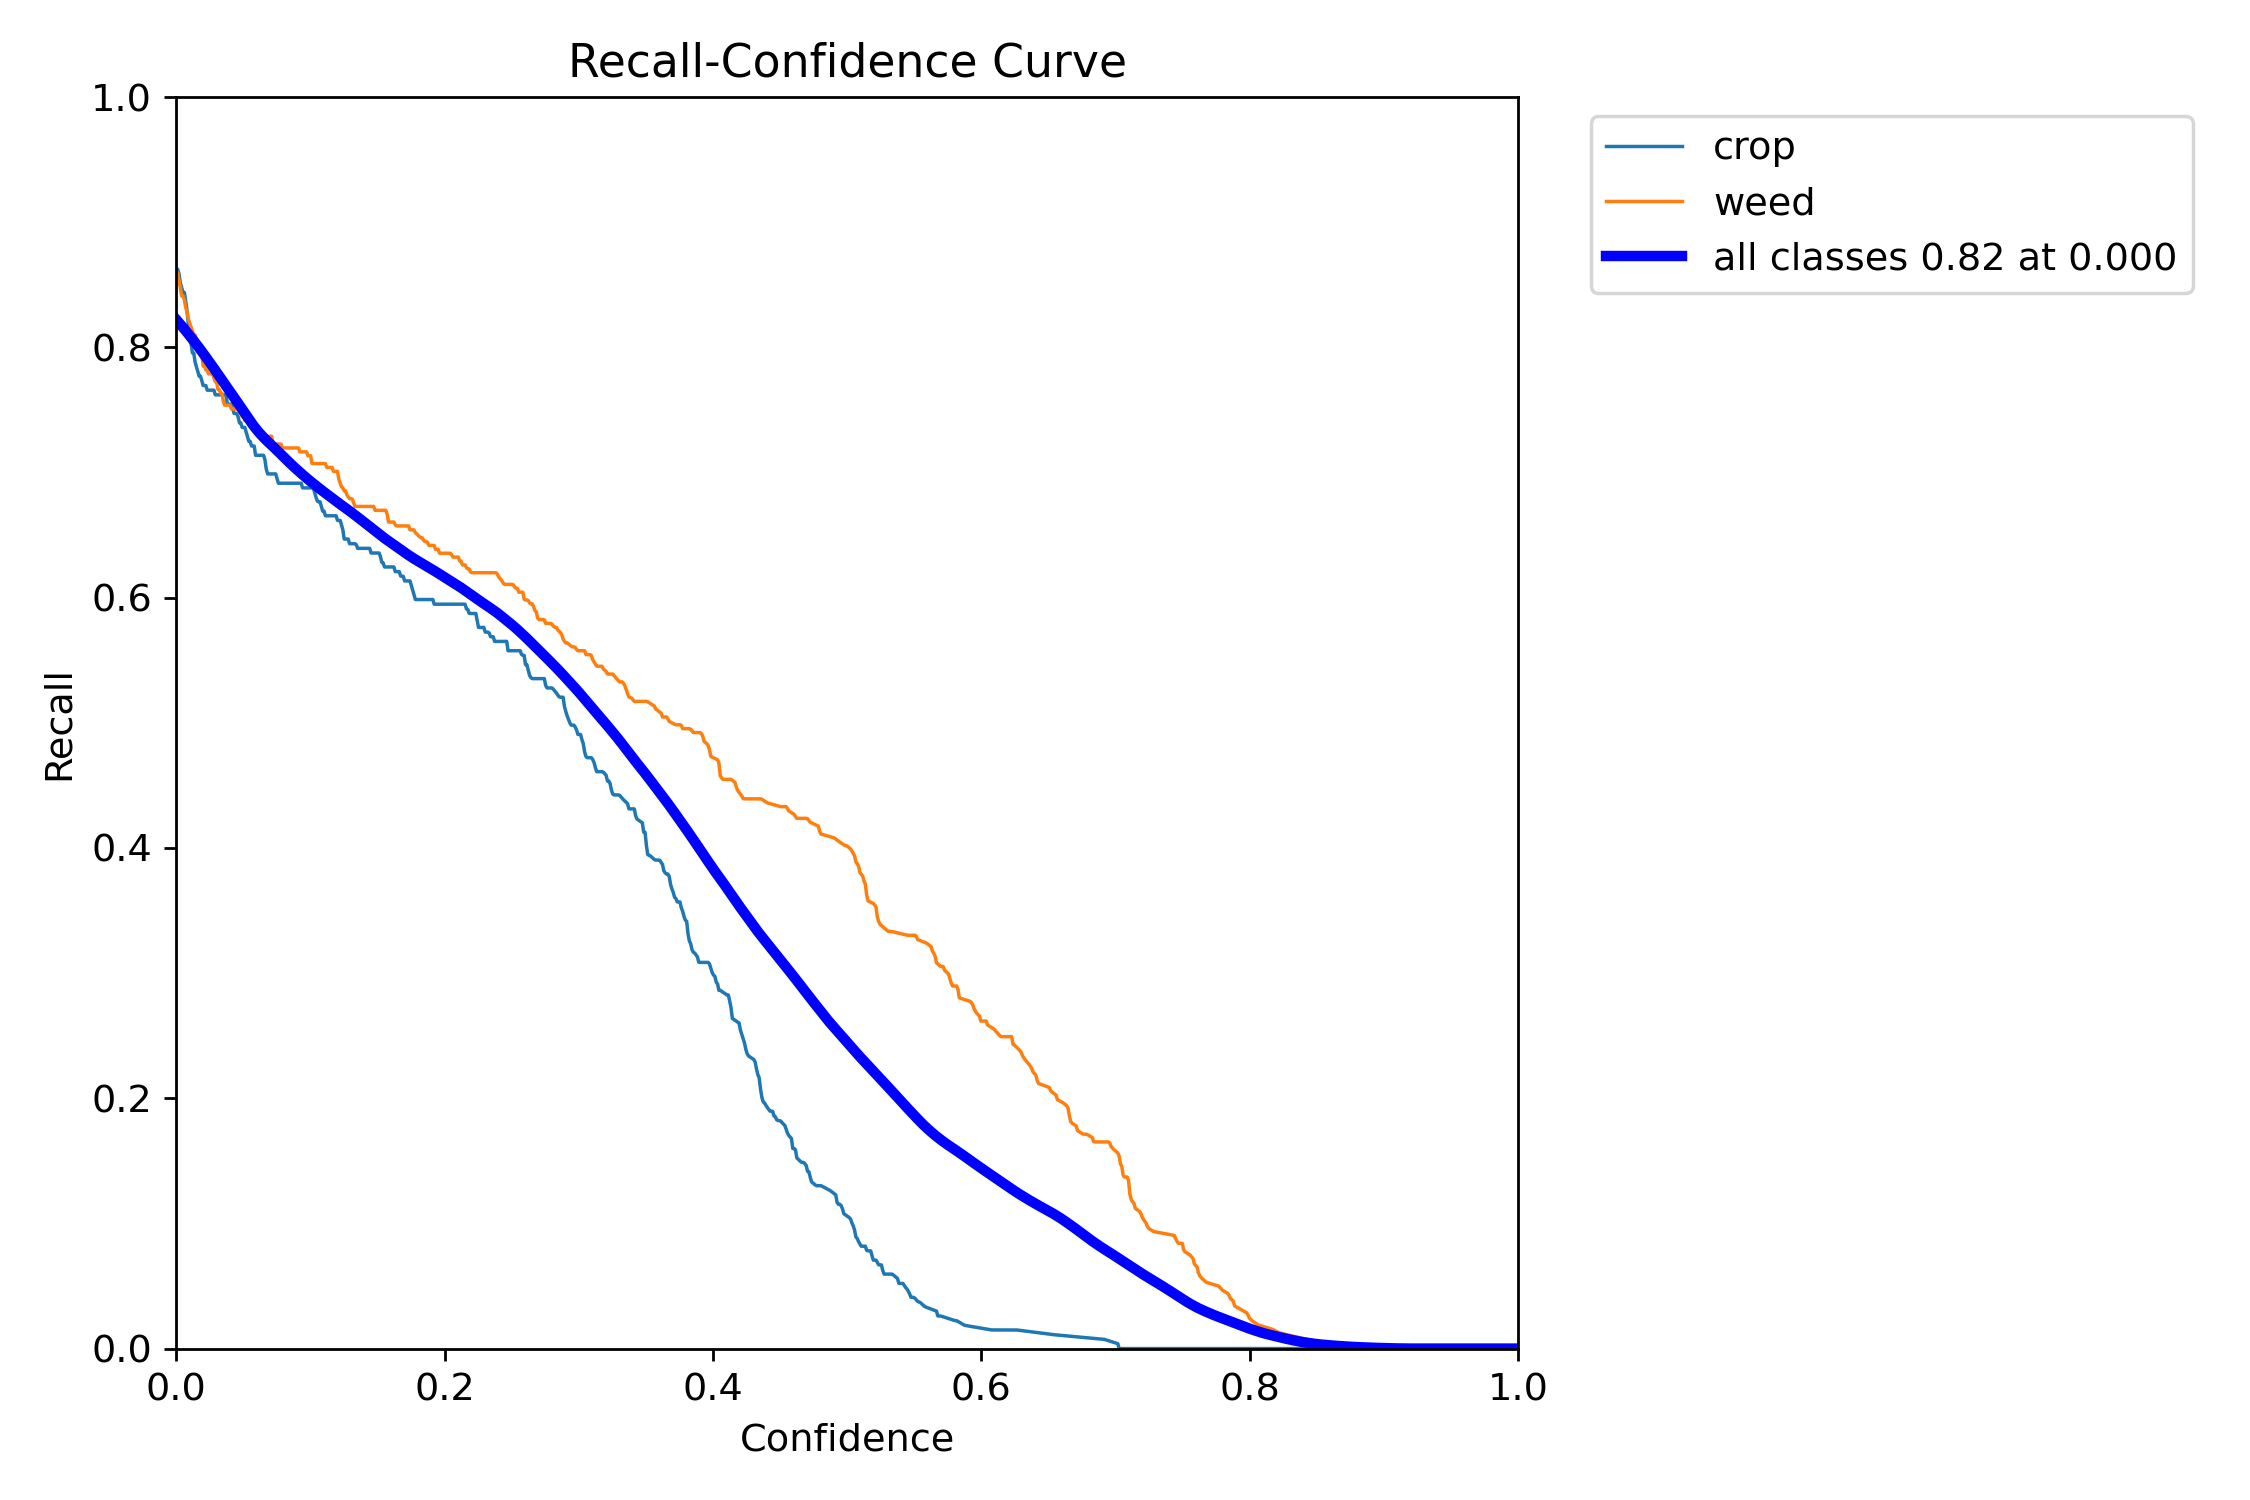

Showing: confusion_matrix.png


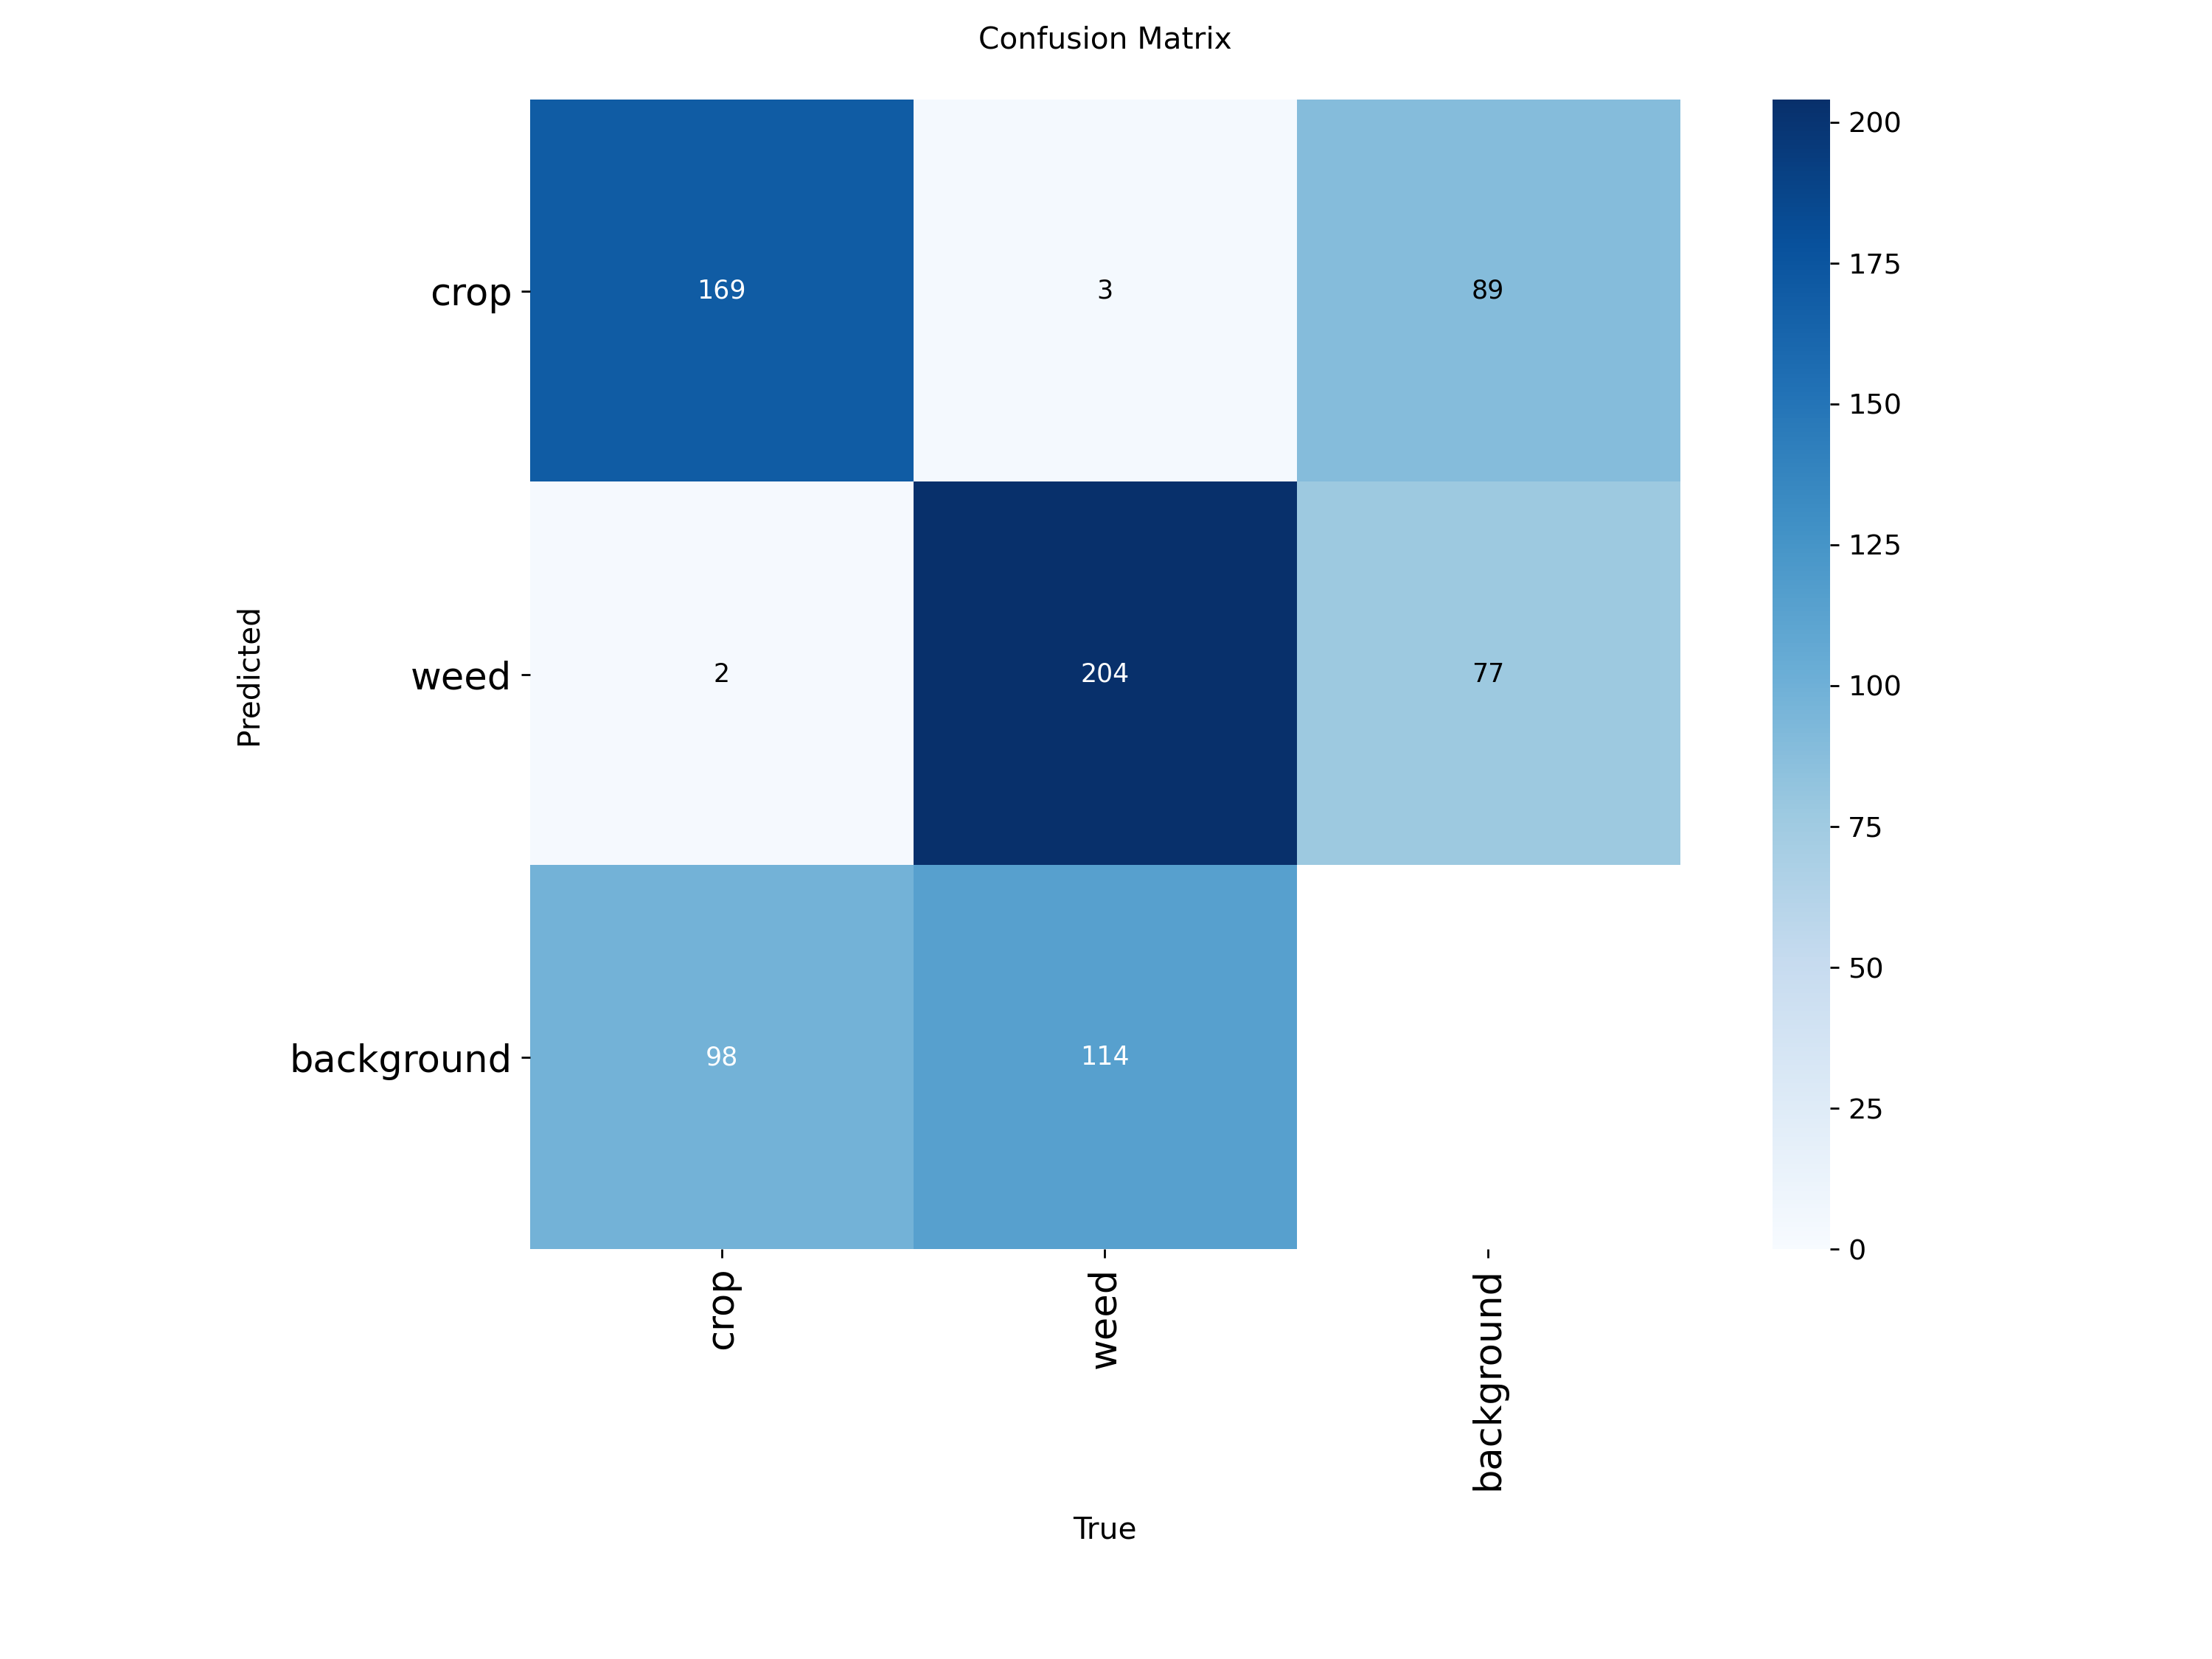

Showing: confusion_matrix_normalized.png


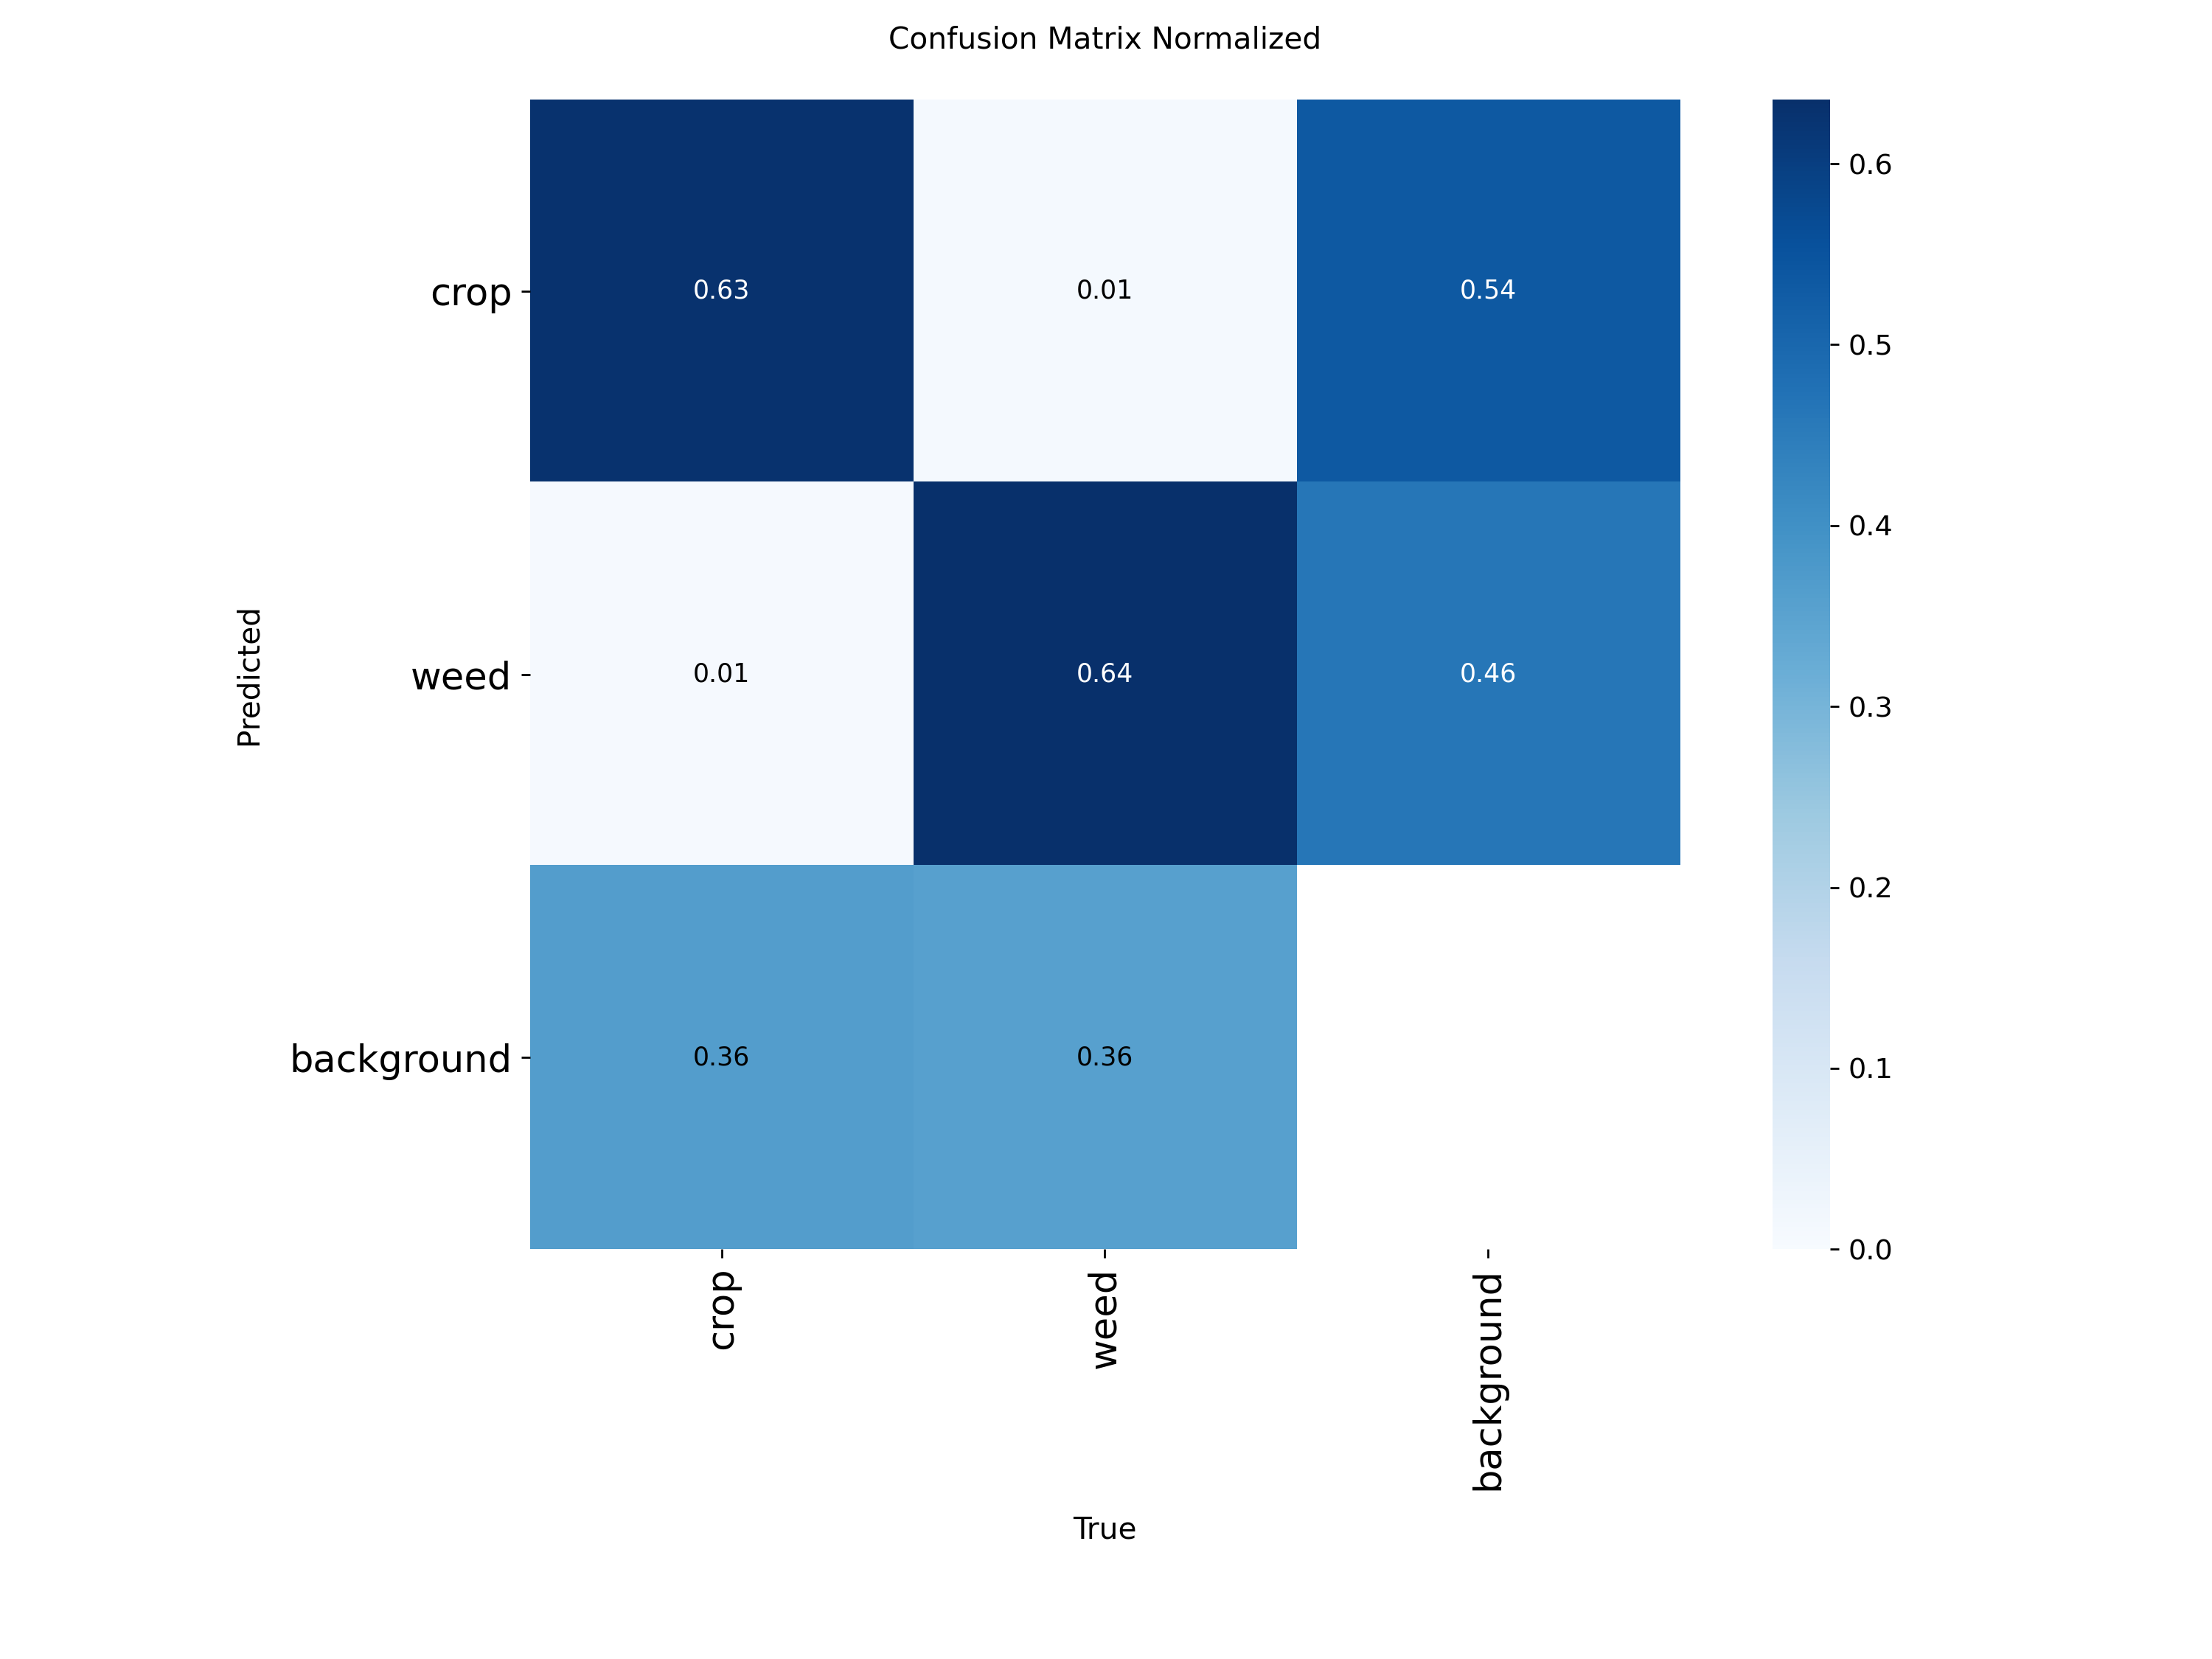

In [ ]:
# ==========================================================
# 🌾 PERFORMANCE EVALUATION SECTION - Quantized YOLOv11n Evaluation (Fixed)
# ==========================================================
from ultralytics import YOLO
from IPython.display import Image, display
import os, glob

# 1️⃣ Load your quantized TFLite model
tflite_path = "/content/yolov_distill_best_int8.tflite"   # path to quantized model
model_tflite = YOLO(tflite_path, task="detect")
print("✅ Quantized YOLOv11n model loaded successfully!")

# 2️⃣ Path to dataset.yaml (from your unzipped Google Drive dataset)
dataset_yaml = "/content/Crop_weedDataset/data.yaml"   # adjust path if needed

# 3️⃣ Run validation (use imgsz = 416)
metrics = model_tflite.val(
    data=dataset_yaml,
    split="val",
    imgsz=416,             # FIXED to match model training size
    save_json=True,
    plots=True
)

# 4️⃣ Display summary metrics
print("\n📈 MODEL PERFORMANCE METRICS:")
print(f"mAP50:        {metrics.box.map50:.4f}")
print(f"mAP50-95:     {metrics.box.map:.4f}")
print(f"Precision:    {metrics.box.mp:.4f}")
print(f"Recall:       {metrics.box.mr:.4f}")
print(f"F1-Score:     {2 * (metrics.box.mp * metrics.box.mr) / (metrics.box.mp + metrics.box.mr + 1e-6):.4f}")
print(f"Inference:    {metrics.speed['inference']:.2f} ms/image")

print("\n✅ Evaluation visuals saved in:")
print(metrics.save_dir)

# 5️⃣ Display Confusion Matrix and PR Curve inline
print("\n🖼️ Displaying Confusion Matrix and PR Curve:")
for img_path in sorted(glob.glob(f"{metrics.save_dir}/*.png")):
    print(f"Showing: {os.path.basename(img_path)}")
    display(Image(filename=img_path))
